In [2]:
from transformers import GPT2LMHeadModel

# size

In [3]:
model_hf = GPT2LMHeadModel.from_pretrained("gpt2") # 124M
sd_hf = model_hf.state_dict()

for k, v in sd_hf.items():
    print(f"{k:<50} {v.shape}")

transformer.wte.weight                             torch.Size([50257, 768])
transformer.wpe.weight                             torch.Size([1024, 768])
transformer.h.0.ln_1.weight                        torch.Size([768])
transformer.h.0.ln_1.bias                          torch.Size([768])
transformer.h.0.attn.c_attn.weight                 torch.Size([768, 2304])
transformer.h.0.attn.c_attn.bias                   torch.Size([2304])
transformer.h.0.attn.c_proj.weight                 torch.Size([768, 768])
transformer.h.0.attn.c_proj.bias                   torch.Size([768])
transformer.h.0.ln_2.weight                        torch.Size([768])
transformer.h.0.ln_2.bias                          torch.Size([768])
transformer.h.0.mlp.c_fc.weight                    torch.Size([768, 3072])
transformer.h.0.mlp.c_fc.bias                      torch.Size([3072])
transformer.h.0.mlp.c_proj.weight                  torch.Size([3072, 768])
transformer.h.0.mlp.c_proj.bias                    torch.Size([76

In [4]:
# 探索 model_hf 的有趣属性
print("=== 模型配置 ===")
print(f"层数 (n_layer): {model_hf.config.n_layer}")
print(f"嵌入维度 (n_embd): {model_hf.config.n_embd}")
print(f"注意力头数 (n_head): {model_hf.config.n_head}")
print(f"词汇表大小 (vocab_size): {model_hf.config.vocab_size}")
print(f"最大位置 (max_position_embeddings): {model_hf.config.max_position_embeddings}")

print("\n=== 参数统计 ===")
total_params = sum(p.numel() for p in model_hf.parameters())
trainable_params = sum(p.numel() for p in model_hf.parameters() if p.requires_grad)
print(f"总参数数: {total_params:,}")
print(f"可训练参数数: {trainable_params:,}")

print("\n=== 子模块 ===")
for name, module in model_hf.named_modules():
    if name and not any(sub in name for sub in ['h.', 'attn.', 'mlp.']):  # 简化输出
        print(f"{name}: {type(module).__name__}")

print("\n=== 设备和模式 ===")
print(f"当前设备: {model_hf.device}")
print(f"训练模式: {model_hf.training}")

=== 模型配置 ===
层数 (n_layer): 12
嵌入维度 (n_embd): 768
注意力头数 (n_head): 12
词汇表大小 (vocab_size): 50257
最大位置 (max_position_embeddings): 1024

=== 参数统计 ===
总参数数: 124,439,808
可训练参数数: 124,439,808

=== 子模块 ===
transformer: GPT2Model
transformer.wte: Embedding
transformer.wpe: Embedding
transformer.drop: Dropout
transformer.h: ModuleList
transformer.ln_f: LayerNorm
lm_head: Linear

=== 设备和模式 ===
当前设备: cpu
训练模式: False


In [5]:
public_attrs = [attr for attr in dir(model_hf) if not attr.startswith('_')]
protected_attrs = [attr for attr in dir(model_hf) if attr.startswith('_') and not attr.startswith('__')]
private_attrs = [attr for attr in dir(model_hf) if attr.startswith('__')]

print("=== Public Attributes/Methods ===")
print(f"Found {len(public_attrs)} public members. Example: {public_attrs[:5]}")
# print(public_attrs)

print("\n=== Protected Attributes/Methods (Internal) ===")
print(f"Found {len(protected_attrs)} protected members. Example: {protected_attrs[:5]}")
# print(protected_attrs)

print("\n=== Private Attributes/Methods (Special) ===")
print(f"Found {len(private_attrs)} private members. Example: {private_attrs[:5]}")
# print(private_attrs)

=== Public Attributes/Methods ===
Found 142 public members. Example: ['T_destination', 'active_adapter', 'active_adapters', 'add_adapter', 'add_memory_hooks']

=== Protected Attributes/Methods (Internal) ===
Found 140 protected members. Example: ['_apply', '_assisted_decoding', '_auto_class', '_backward_compatibility_gradient_checkpointing', '_backward_hooks']

=== Private Attributes/Methods (Special) ===
Found 33 private members. Example: ['__annotations__', '__call__', '__class__', '__delattr__', '__dict__']


In [6]:
# 尽管不推荐，但你可以直接调用受保护的属性/方法
print(f"调用受保护的方法 _get_name(): {model_hf._get_name()}")

调用受保护的方法 _get_name(): GPT2LMHeadModel


In [7]:
# 这是一个如何访问私有属性的例子（假设模型内部有一个 __my_private_var）
# 你需要知道类名 (GPT2LMHeadModel) 和原始属性名
try:
    print(model_hf.__annotations__)
except AttributeError as e:
    print(f"无法访问，因为该属性不存在或名称不正确: {e}")

{'config': <class 'transformers.models.gpt2.configuration_gpt2.GPT2Config'>}


In [8]:
print(f"Is model_hf.config callable? {callable(model_hf.config)}")
print(f"Is model_hf.state_dict callable? {callable(model_hf.state_dict)}")

Is model_hf.config callable? False
Is model_hf.state_dict callable? True


### 1. 私有属性是什么

在 Python 中，私有属性是指以一个或两个下划线开头的属性：

- **单下划线**（`_attribute`）：约定为私有，外部可以访问，但不推荐。
- **双下划线**（`__attribute`）：真正的私有，通过名称修饰（name mangling）隐藏，外部难以直接访问。

在 `dir(model_hf)` 中，私有属性会显示，但通常以 `_` 或 `__` 开头。它们用于内部实现，不应直接使用。

### 2. `nn.Module` 是什么

`nn.Module` 是 PyTorch 的核心类，所有神经网络模块（如层、模型）的基类。它提供：

- **参数管理**：自动跟踪权重和偏置。
- **前向传播**：定义 `forward` 方法。
- **设备管理**：支持 CPU/GPU。
- **钩子**：用于调试或修改行为。

`model_hf` 继承自 `nn.Module`，所以有这些功能。更多详情见 PyTorch 文档。

在面向对象编程中，`attribute` (属性) 和 `method` (方法) 是类的两个基本组成部分，它们的主要区别在于：

1.  **属性 (Attribute)**：
    *   **是什么**：属性是与对象关联的**数据**或**变量**。它存储了对象的状态信息。
    *   **如何使用**：你直接访问它来获取值，不需要加括号 `()`.
    *   **例子**：`model_hf.config` 是一个属性。它存储了模型的配置信息，如层数、头数等。你通过 `model_hf.config` 来读取这些数据。

2.  **方法 (Method)**：
    *   **是什么**：方法是与对象关联的**函数**。它定义了对象可以执行的**行为**或**操作**。
    *   **如何使用**：你需要通过加括号 `()` 来**调用**它，以执行相应的操作。
    *   **例子**：`model_hf.state_dict()` 是一个方法。它是一个动作，被调用时会收集并返回模型的所有参数。

**核心区别：**

*   **属性是“名词”**，描述对象“是什么”（它的状态、特征）。
*   **方法是“动词”**，描述对象“能做什么”（它的行为、能力）。

你可以用 `callable()` 函数来区分它们：



In [9]:
wte_shape = sd_hf["transformer.wte.weight"].shape
wpe_shape = sd_hf["transformer.wpe.weight"].shape

print(f"Vocabulary Size: {wte_shape[0]}")
print(f"Embedding Size: {wte_shape[1]}")
print(f"Position Size: {wpe_shape[0]}")

Vocabulary Size: 50257
Embedding Size: 768
Position Size: 1024


In [10]:
# 1. 打印Q, K, V的长度
print("=== Q, K, V的长度 ===")
# c_attn.weight的形状是 [n_embd, 3 * n_embd]，因为它将Q, K, V合并了
c_attn_shape = sd_hf["transformer.h.0.attn.c_attn.weight"].shape
n_embd = c_attn_shape[0]  # 输入嵌入维度
total_qkv_dim = c_attn_shape[1]  # 输出维度 = 3 * n_embd

# 每个Q, K, V的长度
qkv_length = total_qkv_dim // 3
print(f"输入嵌入维度 (n_embd): {n_embd}")
print(f"c_attn总输出维度: {total_qkv_dim}")
print(f"每个Q, K, V的长度: {qkv_length}")

print("\n=== 模型层数统计 ===")
# 2. 统计Attention层和MLP层的数量
attention_layers = 0
mlp_layers = 0

for key in sd_hf.keys():
    if "attn.c_attn.weight" in key:
        attention_layers += 1
    elif "mlp.c_fc.weight" in key:  # MLP的第一个线性层
        mlp_layers += 1

print(f"Attention层数量: {attention_layers}")
print(f"MLP层数量: {mlp_layers}")
print(f"总的Transformer块数量: {attention_layers}")  # 每个块包含一个attention和一个MLP

print("\n=== 输入和输出向量维度 ===")
# 3. 打印模型的输入和输出向量维度
wte_shape = sd_hf["transformer.wte.weight"].shape
wpe_shape = sd_hf["transformer.wpe.weight"].shape
lm_head_shape = sd_hf["lm_head.weight"].shape

print(f"词汇表大小 (vocab_size): {wte_shape[0]}")
print(f"输入向量维度 (embedding_dim): {wte_shape[1]}")
print(f"最大序列长度 (max_seq_len): {wpe_shape[0]}")
print(f"输出logits维度 (vocab_size): {lm_head_shape[0]}")

print("\n=== 详细信息 ===")
print(f"Token Embedding (wte): {wte_shape}")
print(f"Position Embedding (wpe): {wpe_shape}")
print(f"Language Model Head (lm_head): {lm_head_shape}")
print(f"一个注意力层的c_attn权重: {c_attn_shape}")

=== Q, K, V的长度 ===
输入嵌入维度 (n_embd): 768
c_attn总输出维度: 2304
每个Q, K, V的长度: 768

=== 模型层数统计 ===
Attention层数量: 12
MLP层数量: 12
总的Transformer块数量: 12

=== 输入和输出向量维度 ===
词汇表大小 (vocab_size): 50257
输入向量维度 (embedding_dim): 768
最大序列长度 (max_seq_len): 1024
输出logits维度 (vocab_size): 50257

=== 详细信息 ===
Token Embedding (wte): torch.Size([50257, 768])
Position Embedding (wpe): torch.Size([1024, 768])
Language Model Head (lm_head): torch.Size([50257, 768])
一个注意力层的c_attn权重: torch.Size([768, 2304])


# Word Position Embedding

1.  **`wte` (Word Token Embedding)**
    *   这是 **词元嵌入（Token Embedding）**。
    *   它是一个巨大的查询表（lookup table）。你可以把它想象成一本字典，每一行对应一个词元（一个单词或单词的一部分），每一行都是一个长长的数字列表（向量），这个向量代表了该词元的“含义”。
    *   在你的代码中，`sd_hf["transformer.wte.weight"]` 的形状是 `[50257, 768]`，这意味着：
        *   `50257` 是词汇表的大小（Vocabulary Size），即模型认识多少个不同的词元。
        *   `768` 是嵌入的维度（Embedding Size），即用一个多长的向量来表示一个词元。

2.  **`wpe` (Word Position Embedding)**
    *   这是 **位置嵌入（Position Embedding）**。
    *   Transformer 模型本身无法感知词元的顺序。例如，对于模型来说，“猫追老鼠”和“老鼠追猫”的词元嵌入是一样的。为了解决这个问题，我们需要给模型提供位置信息。
    *   `wpe` 也是一个查询表，它的每一行代表一个位置（第0个、第1个、第2个...）。
    *   在你的代码中，`sd_hf["transformer.wpe.weight"]` 的形状是 `[1024, 768]`，这意味着：
        *   `1024` 是模型能处理的最大序列长度（Position Size）。
        *   `768` 是嵌入维度，必须和词元嵌入的维度相同。

**总结一下它们如何工作：**

当模型处理一句话时，它会为每个词元做两件事：
1.  通过 `wte` 查找到代表这个词元“含义”的向量。
2.  通过 `wpe` 查找到代表这个词元“位置”的向量。

然后，模型将这两个向量**相加**，得到一个既包含“含义”又包含“位置”信息的最终向量。这个最终的向量才是输入到 Transformer 后续网络层进行处理的真正内容。

让我们用一个具体的例子来说明：

对于句子 `The cat sat on the mat`：

1.  第一个 `The` 在**位置0**，它会被加上 `WPE` 矩阵的**第0行**向量。
2.  `cat` 在**位置1**，它会被加上 `WPE` 矩阵的**第1行**向量。
3.  `sat` 在**位置2**，它会被加上 `WPE` 矩阵的**第2行**向量。
4.  ...
5.  第二个 `the` 在**位置4**，它会被加上 `WPE` 矩阵的**第4行**向量。

`WPE[0]`, `WPE[1]`, `WPE[2]`... 这些都是**不同**的向量。

**总结一下关键点：**

*   **WTE (词元嵌入)**：由**词本身**决定。在任何句子中，`cat` 的 WTE 都是一样的。
*   **WPE (位置嵌入)**：由**词的位置**决定。任何在位置1的词（不管是`cat`还是`dog`），都会被加上同一个 `WPE[1]` 向量。

所以，一个词的最终输入向量是 `WTE + WPE`。正是这种组合，让模型既知道这个词是“什么”，又知道它在句子的“哪里”。

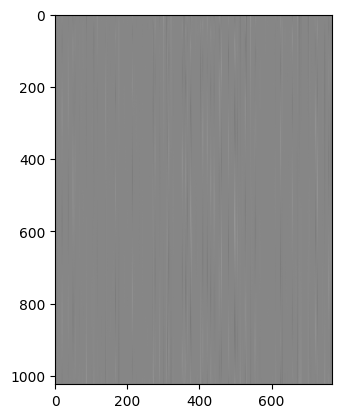

In [11]:
import matplotlib.pyplot as plt

plt.imshow(sd_hf["transformer.wpe.weight"], cmap="gray")
# save the fig
plt.savefig("word_position_embeddings.png")

好的，这张图是GPT-2模型中**词元位置嵌入（Word Position Embedding, WPE）** 权重的热力图。我们可以从中观察到一些有趣的现象：

1.  **明显的垂直条纹**: 这是最显著的特征。这表明，对于嵌入向量中的某一个维度（即图中的某一列），它的值会随着位置（即图中的行）的变化而呈现出一种规律性的、平滑的波动。

2.  **学习到的位置信号**: GPT-2的位置嵌入是**从数据中学习**出来的，而不是像最初的Transformer论文那样使用固定的正弦/余弦函数。然而，这张图显示，模型通过学习最终得到了类似于周期性函数（如正弦波）的模式来编码位置信息。这说明，这种波动的、周期性的信号是表达序列顺序的一种非常有效的方式，以至于模型在训练中自发地“发现”了它。

3.  **每个维度都是一个独特的“时钟”**: 你可以把每一个维度（每一列）想象成一个以不同频率摆动的“时钟”。通过组合这些不同频率的“时钟”的读数，模型可以为每个位置（从0到1023）生成一个独一无二的向量表示，从而精确地知道每个词元在句子中的绝对位置和相对位置。

**总结一下**:

这张热图告诉我们，GPT-2模型学会了一种非常精巧和结构化的方式来理解单词的顺序。它没有使用杂乱无章的随机值，而是为每个位置生成了有规律的、波浪状的信号，这使得模型能够有效地处理和理解长序列文本。

这是一个非常关键的问题！答案是：**不同**。

WPE（位置嵌入）是与词在句子中的**位置**绑定的，而不是与词本身绑定。

让我们用一个具体的例子来说明：

对于句子 `The cat sat on the mat`：

1.  第一个 `The` 在**位置0**，它会被加上 `WPE` 矩阵的**第0行**向量。
2.  `cat` 在**位置1**，它会被加上 `WPE` 矩阵的**第1行**向量。
3.  `sat` 在**位置2**，它会被加上 `WPE` 矩阵的**第2行**向量。
4.  ...
5.  第二个 `the` 在**位置4**，它会被加上 `WPE` 矩阵的**第4行**向量。

`WPE[0]`, `WPE[1]`, `WPE[2]`... 这些都是**不同**的向量。

**总结一下关键点：**

*   **WTE (词元嵌入)**：由**词本身**决定。在任何句子中，`cat` 的 WTE 都是一样的。
*   **WPE (位置嵌入)**：由**词的位置**决定。任何在位置1的词（不管是`cat`还是`dog`），都会被加上同一个 `WPE[1]` 向量。

所以，一个词的最终输入向量是 `WTE + WPE`。正是这种组合，让模型既知道这个词是“什么”，又知道它在句子的“哪里”。

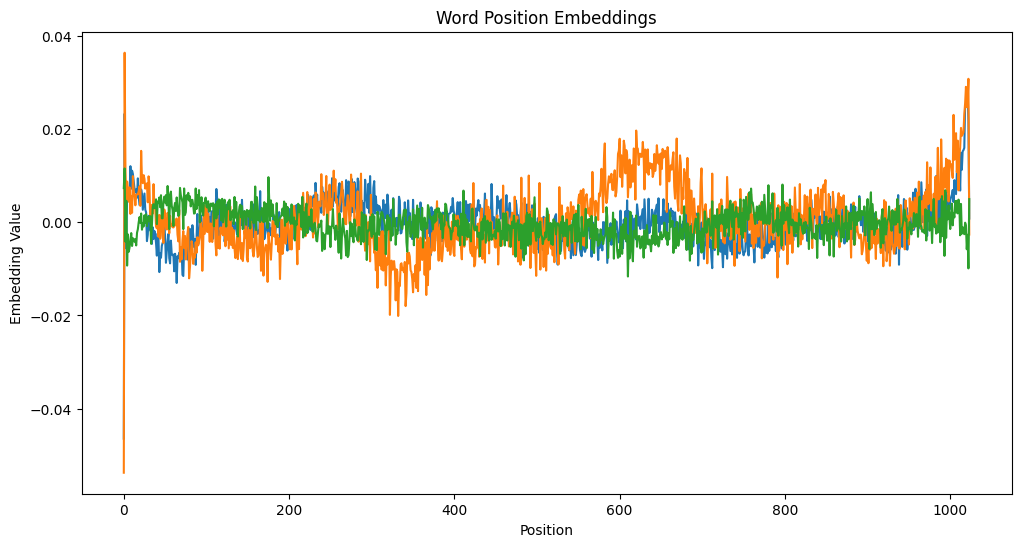

In [12]:
# new fig
plt.figure(figsize=(12, 6))
plt.title("Word Position Embeddings")
plt.xlabel("Position")
plt.ylabel("Embedding Value")
#
plt.plot(sd_hf["transformer.wpe.weight"][:, 150])
plt.plot(sd_hf["transformer.wpe.weight"][:, 200])
# plt.plot(sd_hf["transformer.wpe.weight"][:, 361])
plt.plot(sd_hf["transformer.wpe.weight"][:, 700])
# save the fig
plt.savefig("cols_of_word_position_embeddings.png")


周期性最强的前5列是: [497 762 724 459 361]


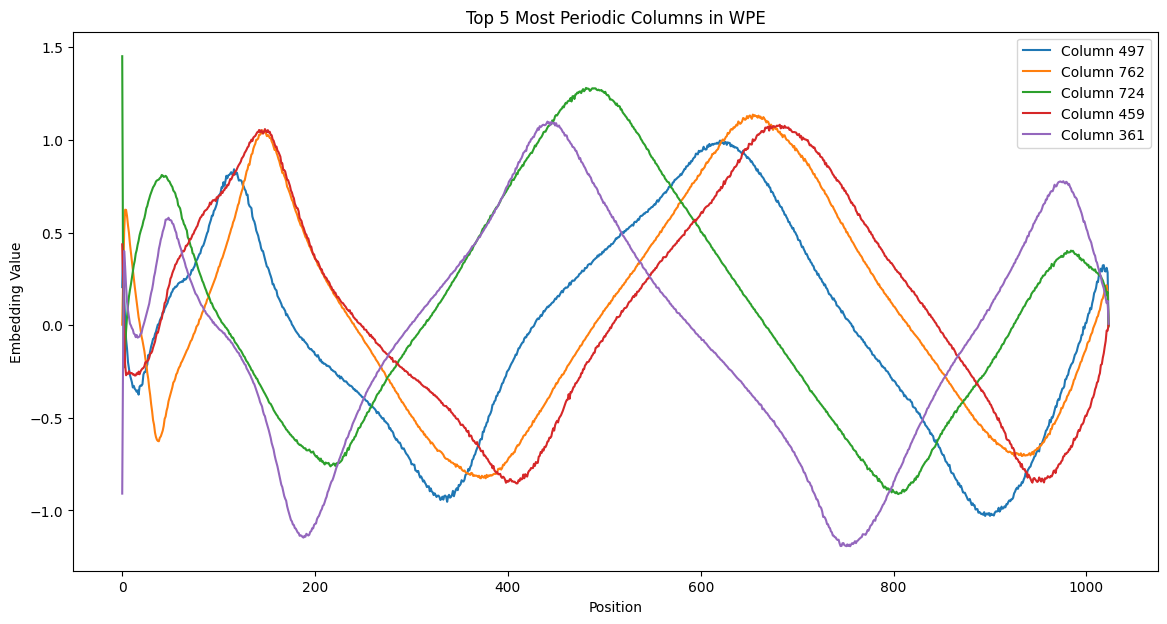

In [13]:
import numpy as np
import matplotlib.pyplot as plt

# 获取WPE权重并转换为numpy数组
wpe_weights = sd_hf["transformer.wpe.weight"].numpy()
n_positions, n_dims = wpe_weights.shape

# --- 找到周期性最强的前5列 ---

# 存储每一列的峰值幅度
peak_magnitudes = []

# 遍历每一列（每一个嵌入维度）
for i in range(n_dims):
    col = wpe_weights[:, i]
    
    # 进行快速傅里叶变换 (FFT)
    fft_vals = np.fft.fft(col)
    
    # 计算频率的幅度（忽略直流分量）
    fft_magnitudes = np.abs(fft_vals[1:n_positions//2])
    
    # 找到当前列的最大峰值
    current_max_peak = np.max(fft_magnitudes)
    peak_magnitudes.append(current_max_peak)

# 获取峰值幅度最高的5列的索引
# np.argsort会返回排序后的索引，我们取最后5个
top_5_indices = np.argsort(peak_magnitudes)[-5:]

print(f"周期性最强的前5列是: {top_5_indices}")

# --- 可视化这5列 ---
plt.figure(figsize=(14, 7))
plt.title("Top 5 Most Periodic Columns in WPE")
plt.xlabel("Position")
plt.ylabel("Embedding Value")

for idx in top_5_indices:
    plt.plot(wpe_weights[:, idx], label=f'Column {idx}')

plt.legend()
plt.show()

周期性最强的前5列是: [497 762 724 459 361]
周期性处于中位数附近的5列是: [143 298 689 124 590]
Figure saved to wpe_periodicity.png


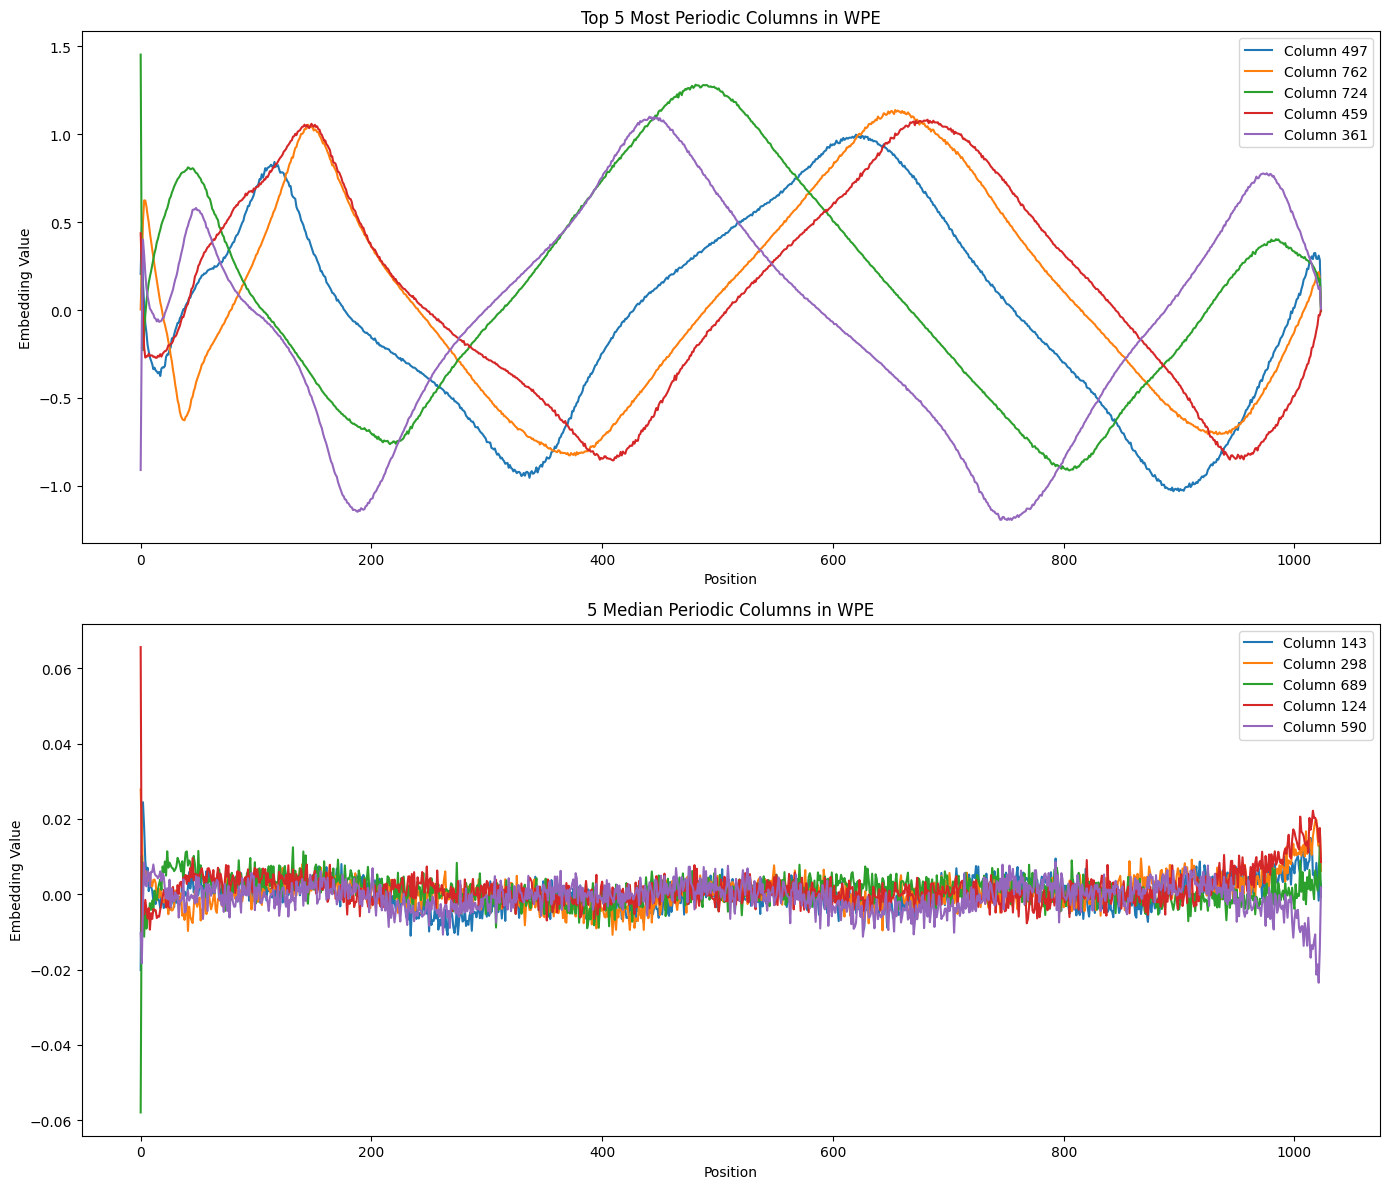

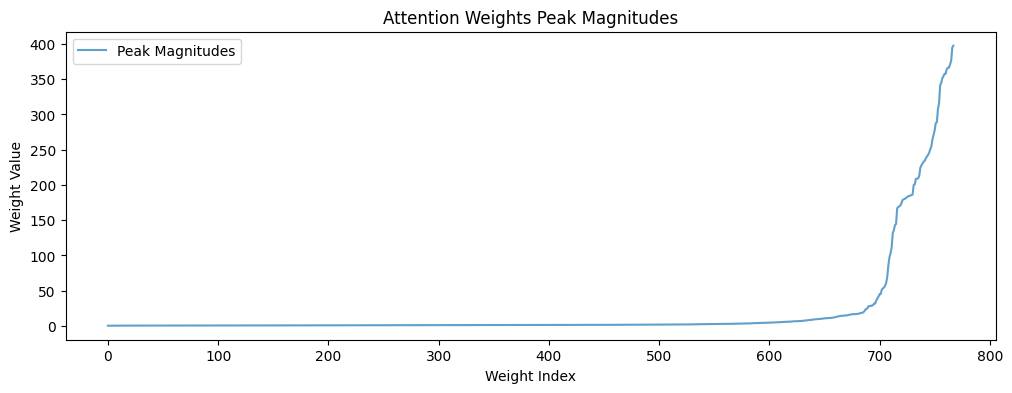

In [14]:
def analyze_and_plot_wpe_periodicity(wpe_weights, save_path=None):
    """
    Analyzes the periodicity of WPE columns, identifies the most and median
    periodic columns, and plots them.

    Args:
        wpe_weights (torch.Tensor or np.ndarray): The Word Position Embedding weights.
        save_path (str, optional): Path to save the figure. If None, shows the plot.
                                   Defaults to None.
    """
    # Ensure wpe_weights is a numpy array
    if hasattr(wpe_weights, 'numpy'):
        wpe_weights = wpe_weights.numpy()

    n_positions, n_dims = wpe_weights.shape

    # --- 对每一列进行FFT并找到峰值幅度 ---
    peak_magnitudes = []
    for i in range(n_dims):
        col = wpe_weights[:, i]
        fft_vals = np.fft.fft(col)
        # 计算频率的幅度（忽略直流分量）
        fft_magnitudes = np.abs(fft_vals[1:n_positions//2])
        # 找到当前列的最大峰值，如果没有非零幅度则为0
        current_max_peak = np.max(fft_magnitudes) if fft_magnitudes.size > 0 else 0
        peak_magnitudes.append(current_max_peak)

    # --- 获取排序后的索引 ---
    # sorted_indices[0] 是周期性最弱的列的索引
    # sorted_indices[-1] 是周期性最强的列的索引
    sorted_indices = np.argsort(peak_magnitudes)

    # --- 找到周期性最强和中位数的列索引 ---
    top_5_indices = sorted_indices[-5:]
    median_point = n_dims // 2
    # 取中位数附近的5个
    median_5_indices = sorted_indices[median_point-2 : median_point+3]

    print(f"周期性最强的前5列是: {top_5_indices}")
    print(f"周期性处于中位数附近的5列是: {median_5_indices}")

    # --- 可视化 ---
    plt.figure(figsize=(14, 12))

    # 图1: 周期性最强的5列
    plt.subplot(2, 1, 1)
    plt.title("Top 5 Most Periodic Columns in WPE")
    plt.xlabel("Position")
    plt.ylabel("Embedding Value")
    for idx in top_5_indices:
        plt.plot(wpe_weights[:, idx], label=f'Column {idx}')
    plt.legend()

    # 图2: 周期性中位数的5列
    plt.subplot(2, 1, 2)
    plt.title("5 Median Periodic Columns in WPE")
    plt.xlabel("Position")
    plt.ylabel("Embedding Value")
    for idx in median_5_indices:
        plt.plot(wpe_weights[:, idx], label=f'Column {idx}')
    plt.legend()

    plt.tight_layout()

    # 保存或显示图像
    if save_path:
        plt.savefig(save_path)
        print(f"Figure saved to {save_path}")
    else:
        plt.show()

    # sort the peak magnitudes, then plot
    peak_magnitudes.sort()
    plt.figure(figsize=(12, 4))
    plt.plot(peak_magnitudes, label="Peak Magnitudes", alpha=0.7)
    plt.title("Attention Weights Peak Magnitudes")
    plt.xlabel("Weight Index")
    plt.ylabel("Weight Value")
    plt.legend()
    plt.show()

# --- 使用函数 ---
# 获取WPE权重
wpe_weights_tensor = sd_hf["transformer.wpe.weight"]
# 调用函数进行分析和绘图
analyze_and_plot_wpe_periodicity(wpe_weights_tensor, save_path="wpe_periodicity.png")

## Rotary Position Embedding

你提出了一个非常深刻且前沿的问题！这直击了当前大语言模型架构演进的核心。

简单回答是：**位置编码本身至关重要，但实现它的方式正在不断进化。** 你提到的DeepSeek等新模型的变化，正反映了这种趋势。

让我们分点来解析：

1.  **为什么位置编码是不可或缺的？**
    *   Transformer的核心注意力机制天生不理解“顺序”。如果没有位置信息，“猫追老鼠”和“老鼠追猫”在它看来是一样的，因为输入的词嵌入集合是相同的。
    *   位置编码（无论是哪种形式）的唯一目的，就是将**顺序信息**注入到模型中，让模型知道每个词在序列中的“哪里”。没有它，模型就无法理解语法、因果关系等依赖于顺序的复杂语言现象。

2.  **“学习式” vs "固定式" 的权衡**
    *   **学习式位置嵌入 (Learned PE)**：就像你正在分析的GPT-2，它将位置编码视为一组可训练的参数（`wpe`矩阵）。
        *   **优点**：非常灵活，模型可以从数据中“学习”出它认为最优的位置表示方式。从你之前的热力图可以看到，它确实学到了类似周期函数的有效结构。
        *   **缺点**：
            *   **外推性差**：如果模型训练时最大长度是1024，它就不知道第1025个位置的嵌入是什么，这限制了它处理超长文本的能力。
            *   增加了额外的模型参数。

    *   **固定式/函数式位置嵌入 (Fixed PE)**：
        *   **优点**：
            *   **外推性好**：因为它们是基于数学公式（如正弦/余弦函数）生成的，理论上可以为任意长的序列生成位置编码。
            *   不增加模型参数。
        *   **缺点**：模式是固定的，可能不如学习到的模式那么“量身定制”。

3.  **DeepSeek等新模型的趋势：RoPE (旋转位置编码)**
    你提到DeepSeek改用固定的，这非常准确。现在很多先进的模型（包括Llama、DeepSeek等）都转向了一种更先进的“固定式”变体，叫做**旋转位置编码（Rotary Position Embedding, RoPE）**。

    *   RoPE不再是简单地将位置向量“加”到词向量上。
    *   它通过一个固定的数学变换（旋转矩阵），根据词的绝对位置来“旋转”Query和Key向量。
    *   这样做巧妙地在模型中引入了**相对位置**信息。注意力分数会自然地依赖于两个词之间的距离，而不是它们的绝对位置。这被证明在性能和处理长文本方面都非常有效。

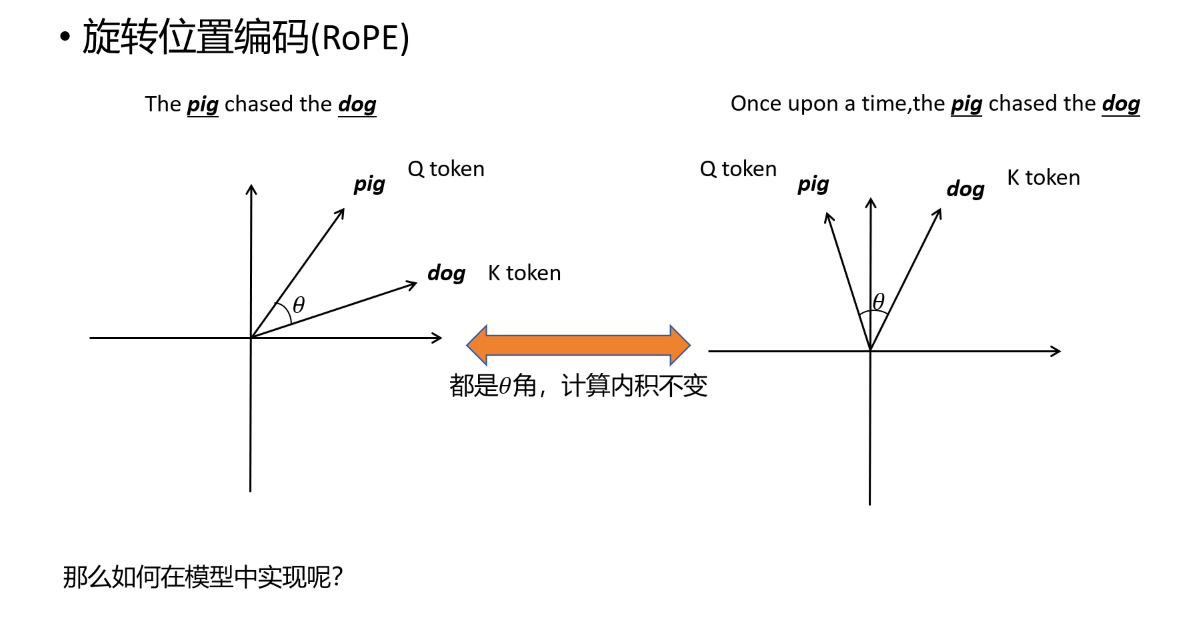

**总结：**

*   **位置编码很重要吗？** **是的，极其重要**。它是Transformer理解顺序的基石。
*   **为什么DeepSeek等新模型不用GPT-2那种学习式WPE了？** 因为业界发现，像**RoPE**这样基于固定数学公式、又能巧妙编码**相对位置**信息的方法，在处理长文本和模型性能上表现更优。

所以，不是位置编码不重要了，而是实现它的技术从“学习绝对位置”进化到了更高效的“**计算相对位置**”。你正在做的分析，正是理解这一技术演进的绝佳起点。

好的，我们来深入解析一下RoPE（旋转位置编码）的原理，包括其背后的数学公式。

### 核心思想：从“相加”到“旋转”

传统的位置编码（如GPT-2的WPE或原始Transformer的正弦编码）是将一个“位置向量”**加**到词嵌入向量上。

**RoPE的革命性之处在于，它不“加”任何东西，而是根据词的绝对位置 `m` 来“旋转”词的Query和Key向量。**

这个操作非常巧妙，因为它使得两个向量在旋转后的点积结果，仅仅和它们的**相对位置 `m-n`** 相关。这正是我们希望注意力机制关注的。

### 数学原理：从二维到高维

为了理解RoPE，我们先从最简单的二维向量旋转开始。

#### 1. 二维向量旋转

假设我们有一个二维向量 $\vec{q} = (x, y)$。要将它逆时针旋转一个角度 $\theta$，我们需要左乘一个旋转矩阵：

$ R_{\theta} = \begin{pmatrix} \cos\theta & -\sin\theta \\ \sin\theta & \cos\theta \end{pmatrix} $

旋转后的向量 $\vec{q'}$ 就是：

$ \vec{q'} = R_{\theta} \vec{q} = \begin{pmatrix} x\cos\theta - y\sin\theta \\ x\sin\theta + y\cos\theta \end{pmatrix} $

这可以用复数更简洁地表示。如果把 $\vec{q}$ 看作复数 $q = x + iy$，那么旋转就是乘以 $e^{i\theta}$：

$ q' = q \cdot e^{i\theta} = (x+iy)(\cos\theta + i\sin\theta) = (x\cos\theta - y\sin\theta) + i(x\sin\theta + y\cos\theta) $

实部和虚部正好对应旋转后向量的两个分量。

#### 2. RoPE在高维向量上的应用

现在，我们把这个思想扩展到LLM中的高维向量（例如，维度为 `d`）。RoPE的做法是：

1.  **两两分组**：将一个 `d` 维的向量（无论是Q还是K）看作 `d/2` 个二维向量的组合。
    $ \vec{q} = (q_0, q_1, q_2, q_3, \dots, q_{d-2}, q_{d-1}) $
    分组后得到：$ (q_0, q_1), (q_2, q_3), \dots, (q_{d-2}, q_{d-1}) $

2.  **定义旋转角度**：对于一个在位置 `m` 的词，其第 `i` 组二维向量 $(q_{2i}, q_{2i+1})$ 的旋转角度被定义为 $m\theta_i$。这里的 `m` 是绝对位置，而 $\theta_i$ 是一个预先设定的、与维度 `i` 相关的固定频率（类似于正弦编码中的频率）：
    $ \theta_i = 10000^{-2i/d} $
    *   注意：`i` 的范围是从 `0` 到 `d/2 - 1`。
    *   这个公式使得向量的不同部分以不同的速度旋转。低维部分（`i`小）旋转快（高频），高维部分（`i`大）旋转慢（低频）。

3.  **执行旋转**：对每一个二维向量组应用其对应的旋转。对于位置 `m` 的Query向量 $\vec{q}_m$ 的第 `i` 组 $(q_{2i}, q_{2i+1})$，旋转后的结果 $\vec{q'}_m$ 的对应分量是：
    $ \begin{pmatrix} q'_{2i} \\ q'_{2i+1} \end{pmatrix} = \begin{pmatrix} \cos(m\theta_i) & -\sin(m\theta_i) \\ \sin(m\theta_i) & \cos(m\theta_i) \end{pmatrix} \begin{pmatrix} q_{2i} \\ q_{2i+1} \end{pmatrix} $

    对所有 `d/2` 组都执行这个操作，就得到了完整的、包含了位置信息的向量 $\vec{q'}_m$。对Key向量 $\vec{k}_n$ 也做完全相同的操作。

#### 3. 关键属性：点积只与相对位置有关

现在到了最神奇的部分。我们来计算旋转后的Query向量 $\vec{q'}_m$ 和Key向量 $\vec{k'}_n$ 的点积。由于旋转是逐组进行的，它们的总点积等于所有组点积的和。我们只看第 `i` 组：

$ (q'_{2i}, q'_{2i+1}) \cdot (k'_{2i}, k'_{2i+1}) $

使用复数表示会更清晰。令 $q_i = q_{2i} + iq_{2i+1}$ 和 $k_i = k_{2i} + ik_{2i+1}$。
旋转后的复数为：
$ q'_i = q_i \cdot e^{im\theta_i} $
$ k'_i = k_i \cdot e^{in\theta_i} $

它们的点积等价于一个复数乘以另一个复数的共轭，然后取实部：$ \text{Re}(q'_i \cdot k'^{*}_i) $。

$ q'_i \cdot k'^{*}_i = (q_i e^{im\theta_i}) \cdot (k_i e^{in\theta_i})^{*} $
$ = (q_i e^{im\theta_i}) \cdot (k_i^{*} e^{-in\theta_i}) $
$ = (q_i k_i^{*}) \cdot e^{i(m-n)\theta_i} $

我们看到，旋转后的点积结果，是**原始向量的点积** $ (q_i k_i^{*}) $ 再乘以一个只依赖于**相对位置 `m-n`** 的旋转项 $ e^{i(m-n)\theta_i} $。

将所有 `d/2` 组的结果加起来，最终的注意力分数（Softmax之前）就巧妙地包含了原始的语义相似度（来自 $\vec{q}_m \cdot \vec{k}_n$）和它们的相对位置信息（来自旋转）。

### 总结

*   **RoPE** 将位置信息通过**旋转**的方式注入到Q和K向量中。
*   它将高维向量**两两分组**，并将每一组视为一个二维向量（或复数）。
*   每一组的旋转角度由**绝对位置 `m`** 和一个**固定频率 `θ_i`** 共同决定。
*   最终的魔法在于，经过旋转后，两个向量的点积**只依赖于它们的相对位置 `m-n`**，这使得注意力机制能够自然地理解词与词之间的距离关系，同时还具备了优秀的长度外推能力。

很好的问题！这直接关系到我们刚才讨论的RoPE所带来的优势。

GPT-2使用学习式位置嵌入（WPE），所以它的序列长度被严格限制在训练时设定的1024。

而DeepSeek和Llama系列模型因为采用了RoPE，情况就灵活得多了：

1.  **Llama (例如 Llama 2)**:
    *   标准的Llama 2模型训练时的上下文窗口是 **4096个token**。这已经是GPT-2的4倍了。

2.  **DeepSeek**:
    *   DeepSeek模型家族以其超长的上下文窗口而闻名。例如，**DeepSeek Coder** 和 **DeepSeek-LLM 67B** 模型支持 **16,384个token** 的上下文长度。
    *   一些更新的模型甚至在向更长的窗口（如32K或更长）发展。

### 为什么它们能处理这么长的序列？

这正是**RoPE**的威力所在：

*   **良好的外推性**: RoPE是基于数学公式计算的，理论上可以为无限长的序列生成位置编码。虽然在实际中，模型在处理远超其训练长度的序列时性能会下降，但它的基础能力远强于有硬性限制的学习式位置嵌入。
*   **长度扩展技术**: 基于RoPE的这个特性，社区和研究人员开发出了多种技术（如NTK-aware scaling, Positional Interpolation - PI）来“扩展”模型的上下文窗口。这意味着一个在4K长度上训练的模型，可以通过微调或在推理时应用这些技巧，使其能有效处理16K甚至更长的文本，而这是GPT-2架构很难做到的。

**总结一下**：

| 模型 | 位置编码方式 | 标准上下文长度 |
| :--- | :--- | :--- |
| **GPT-2** | 学习式 (WPE) | **1024** (硬性限制) |
| **Llama 2** | 旋转式 (RoPE) | **4096** (可扩展) |
| **DeepSeek** | 旋转式 (RoPE) | **16,384** (或更长，可扩展) |

所以，从GPT-2到Llama/DeepSeek的演进，不仅仅是模型变大了，更关键的是像RoPE这样的底层技术革新，直接解锁了模型处理长文本的核心能力。

## 人类的工作记忆

你提出了一个非常深刻、触及问题本质的对比！

简单回答是：**不，人类在“单次处理”时的工作记忆（Working Memory）远没有这么长，但我们用完全不同的、更高效的机制来处理长信息。**

我们可以从两个层面来理解这个差异：

### 1. 工作记忆 (Working Memory) vs. LLM的上下文窗口

*   **人类的工作记忆**：这是我们大脑中能够**同时保持活跃并进行处理**的信息。它非常有限，通常被认为只能容纳 **4-7个信息“块” (chunks)**。比如，我们可以记住一个电话号码，但很难同时记住三个。当我们阅读时，我们只能清晰地记得当前句子和上一个段落的大意，而无法一字不差地记住5页前的内容。
*   **LLM的上下文窗口 (如16K tokens)**：这更像一个**巨大的、完美的短期“内存条” (RAM)**。模型可以**一字不差地、无遗漏地**访问这个窗口内的任何一个词。它可以在第16000个token处，精确地引用第50个token的某个词。这是**超人级别**的 verbatim（逐字）记忆能力。

**结论1：在“一次性、无损”记忆大量文本方面，LLM远超人类。**

### 2. 抽象、压缩与长时记忆 (Abstraction, Compression & Long-term Memory)

这才是人类真正的优势所在。当我们阅读一本长篇小说时，我们并不会把所有文字都塞进大脑。我们会做几件事：

*   **实时压缩与抽象**：我们的大脑会不断地将读过的内容提炼成**更高层次的概念和摘要**。我们不记“哈利·波特收到了来自霍格沃茨的信”，我们记“哈利发现了自己的巫师身份”。
*   **建立心智模型 (Mental Model)**：我们会构建一个关于故事世界、人物关系、情节发展的动态模型。当读到后面时，我们是根据这个**被压缩和抽象过的模型**来理解新内容，而不是去回忆几百页前的原文。
*   **高效索引与检索**：我们的长时记忆像一个巨大的、关联式的数据库。当读到“斯内普”这个名字时，大脑会自动“检索”出与他相关的所有关键记忆（他的性格、过去的事件、与其他人的关系），并将其带入当前的工作记忆中来辅助理解。

**结论2：人类通过“有损压缩”和“建立模型”的方式，实现了对几乎无限长上下文的理解。**

### 总结

| 特性 | 大语言模型 (LLM) | 人类 |
| :--- | :--- | :--- |
| **工作记忆** | **巨大、无损**的上下文窗口 (如16K) | **非常小**，但灵活 (4-7个信息块) |
| **记忆方式** | 逐字记录 (Verbatim) | **抽象、压缩、建立模型** |
| **长文本处理** | 依赖于窗口大小，超出则遗忘 | 通过长时记忆和检索，理论上**无上限** |
| **优势** | 在窗口内进行精确的信息查找和关联 | 对信息进行深层理解、推理和归纳 |

所以，LLM增加上下文窗口，是在用“暴力”的计算和内存，来弥补它**缺乏人类那种高效的、动态的抽象和记忆压缩机制**的短板。它试图通过把整本书都放进“内存条”的方式，来模拟人类读完一本书后形成的整体理解。

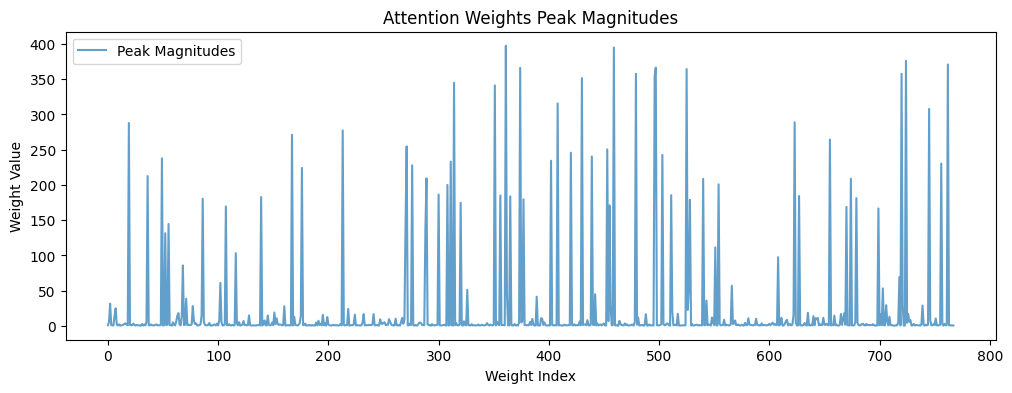

In [15]:
# plot peak_magnitudes, which is a list of 1024
plt.figure(figsize=(12, 4))
plt.plot(peak_magnitudes, label="Peak Magnitudes", alpha=0.7)
plt.title("Attention Weights Peak Magnitudes")
plt.xlabel("Weight Index")
plt.ylabel("Weight Value")
plt.legend()
plt.show()

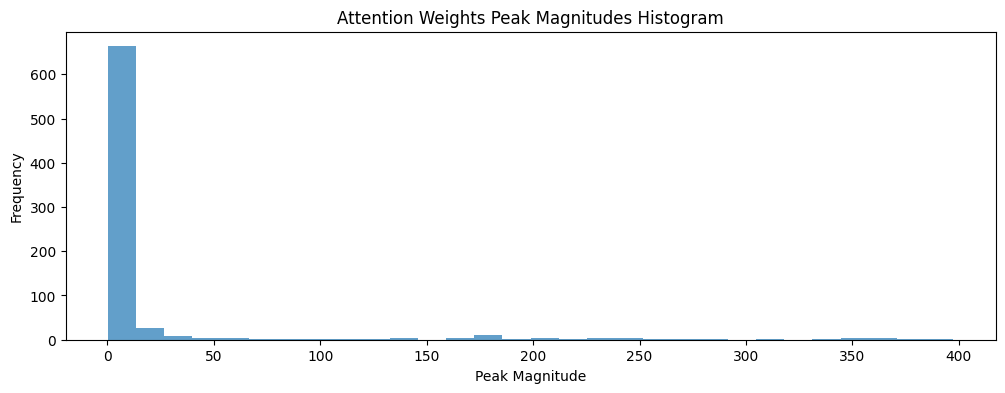

In [16]:
# plot the histogram of peak_magnitudes, which is a list of 1024
plt.figure(figsize=(12, 4))
plt.hist(peak_magnitudes, bins=30, alpha=0.7)
plt.title("Attention Weights Peak Magnitudes Histogram")
plt.xlabel("Peak Magnitude")
plt.ylabel("Frequency")
plt.show()

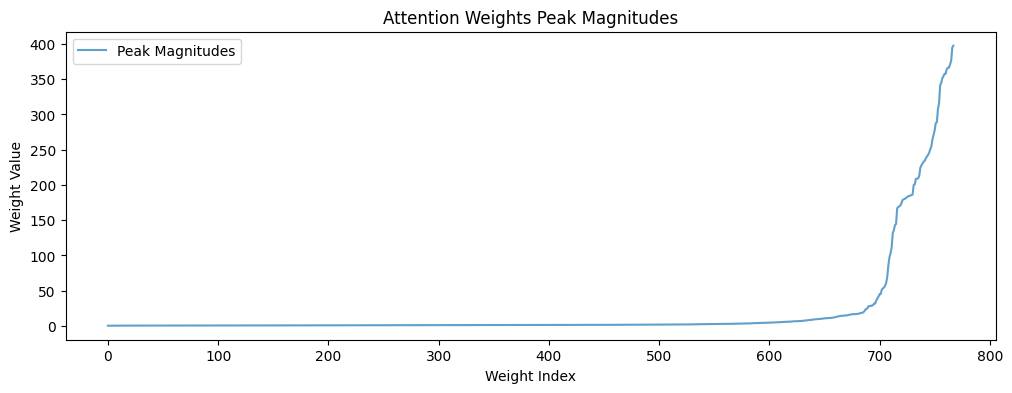

In [17]:
# sort the peak magnitudes, then plot
peak_magnitudes.sort()
plt.figure(figsize=(12, 4))
plt.plot(peak_magnitudes, label="Peak Magnitudes", alpha=0.7)
plt.title("Attention Weights Peak Magnitudes")
plt.xlabel("Weight Index")
plt.ylabel("Weight Value")
plt.legend()
plt.show()

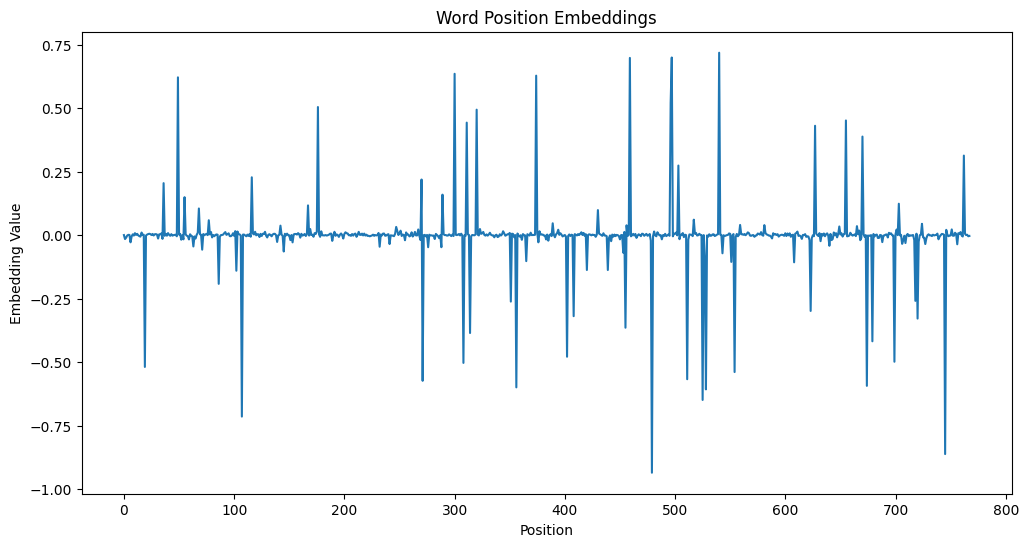

In [18]:
# new fig
plt.figure(figsize=(12, 6))
plt.title("Word Position Embeddings")
plt.xlabel("Position")
plt.ylabel("Embedding Value")
#
# plt.plot(sd_hf["transformer.wpe.weight"][0, :])
plt.plot(sd_hf["transformer.wpe.weight"][100, :])
# plt.plot(sd_hf["transformer.wpe.weight"][250, :])
# plt.plot(sd_hf["transformer.wpe.weight"][700, :])
# save the fig
plt.savefig("rows_of_word_position_embeddings.png")

周期性最强的前5列是: [4 3 2 1 0]
周期性处于中位数附近的5列是: [212 441 500 976 505]
Figure saved to wpe_periodicity.png


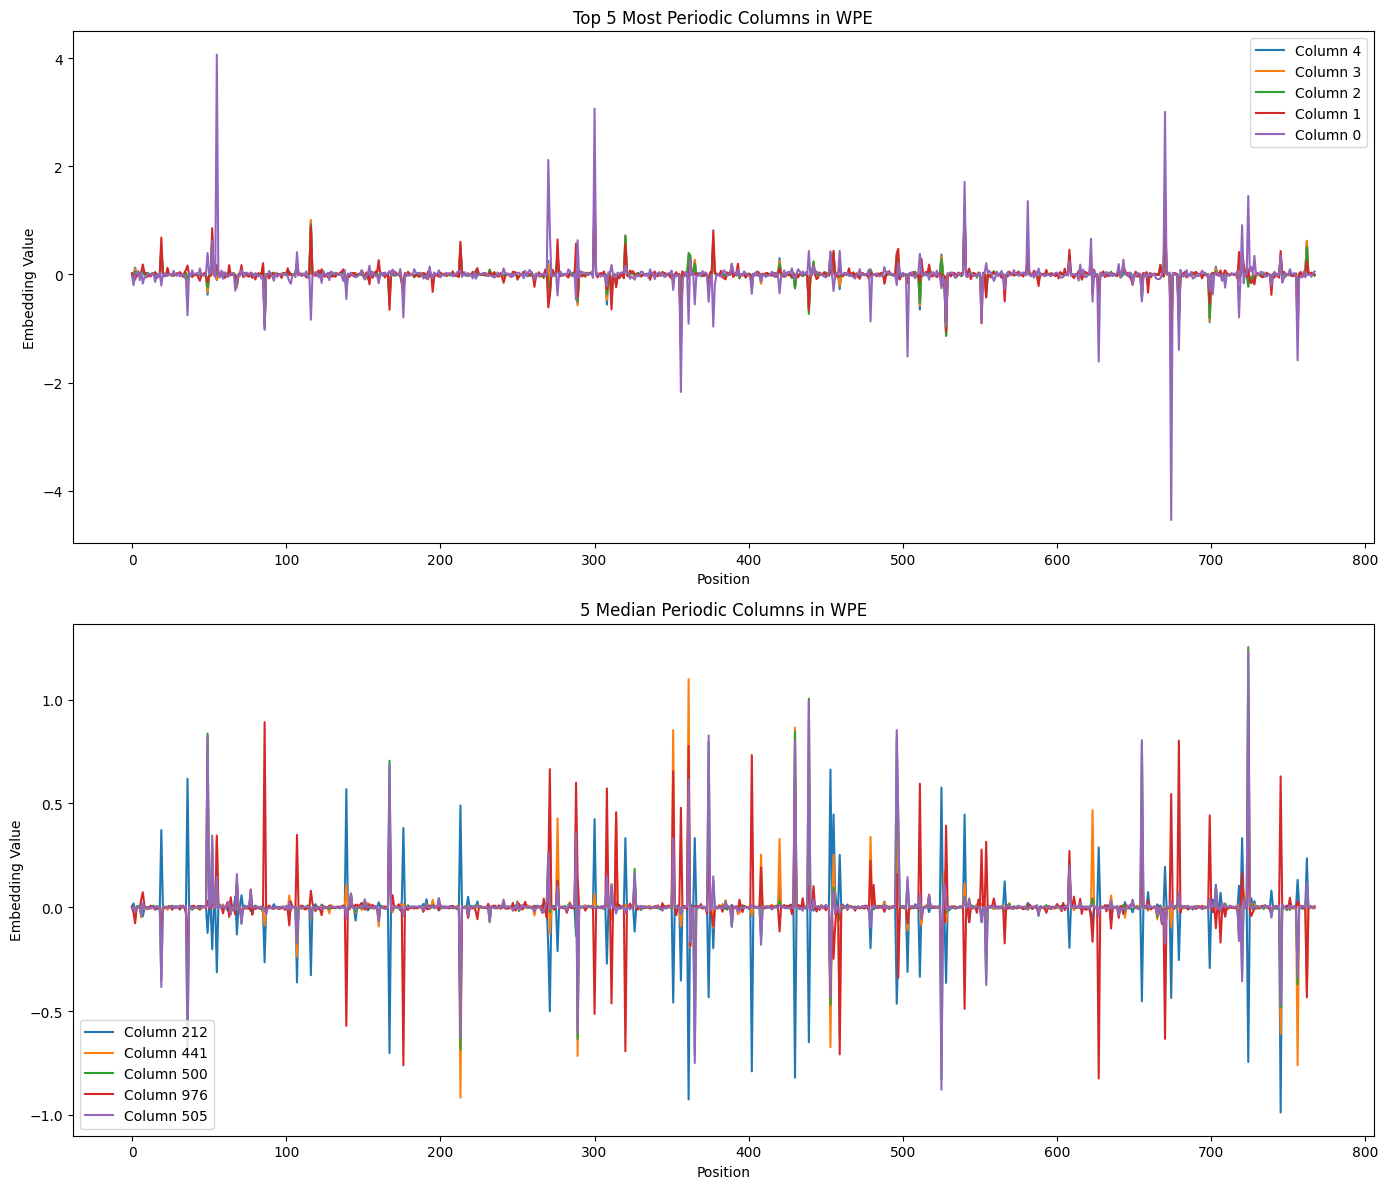

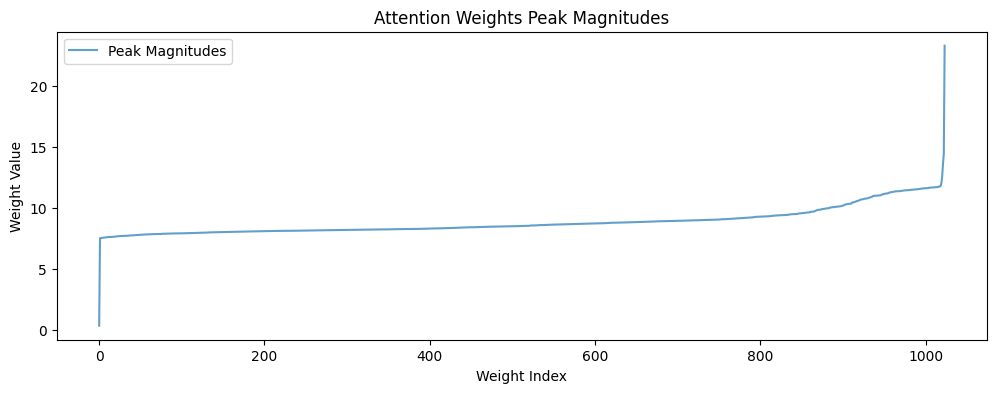

In [19]:
analyze_and_plot_wpe_periodicity(wpe_weights_tensor.T, save_path="wpe_periodicity.png")

你观察到的现象非常有趣，这揭示了高维嵌入向量的一个核心特点。这张图展示的是**某一个固定位置**（例如，第100个位置）的嵌入向量，它有768个维度。

之所以某一行会长这样，有很多尖峰，主要有以下几个原因：

1.  **为了独特性和可区分性 (Uniqueness and Distinguishability)**：
    *   模型的首要任务是为每一个位置（从0到1023）生成一个**独一无二的“指纹”**。
    *   在一个高维空间（这里是768维）中，最有效的方式不是让所有维度的值都平滑分布，而是在少数几个维度上拥有非常突出（或正或负）的值，而其他大部分维度的值都接近于零。
    *   这些**尖峰**就像这个位置“指纹”上最关键的特征点。正是这些尖峰的位置和高度，让位置100的向量与位置101的向量能够被模型清晰地区分开。

2.  **学习到的特征表示 (Learned Feature Representation)**：
    *   这些尖峰不是随机的。模型在训练中发现，激活某些特定的维度（即产生尖峰）对于编码位置信息最有效。
    *   你可以把每个维度想象成一个特征。一个尖峰意味着对于当前这个位置，模型认为“激活”这个特征非常重要。

3.  **稀疏性 (Sparsity)**：
    *   这种大部分值接近零、少数有尖峰的模式，是一种**稀疏表示**。在神经网络中，稀疏表示被认为是一种高效的编码信息的方式。它能用更少的“能量”（非零值）来存储和区分信息。

**总结一下**：

把WPE矩阵的**行**和**列**对比来看，会非常有启发性：

*   **看一列**：我们看到的是一个**平滑的、类似周期函数的波**。它表示一个**特征维度**是如何随着**位置**变化来编码信息的。
*   **看一行**：我们看到的是一个**带有尖峰的、类似噪声的信号**。它表示一个**固定位置**是如何通过在768个**特征维度**上进行组合，来创造一个**独一无二的身份标识**的。

所以，这些尖峰正是模型为区分不同位置而学习到的、最关键的“密码”。

总之，GPT2的WPE中:

1. 多数列（>50%）的振幅很小。
2. 少数列（<50%）的振幅很大。并且呈现周期性。

# Attention

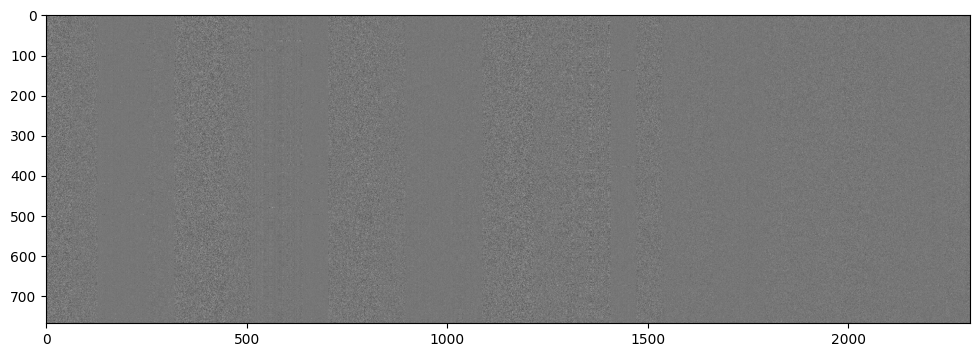

In [20]:
QKV = sd_hf["transformer.h.1.attn.c_attn.weight"]
plt.figure(figsize=(12, 4))
plt.imshow(QKV, cmap="gray")
plt.savefig("attention_weights.png")
plt.show()

完整的 c_attn.weight 形状: torch.Size([768, 2304])
嵌入维度 (n_embd): 768
宽度是嵌入维度的 3.0 倍
拆分后 Q, K, V 的形状: torch.Size([768, 768]), torch.Size([768, 768]), torch.Size([768, 768])

Q, K, V 权重的均值: -0.000153, 0.000235, 0.000002
Q, K, V 权重的标准差: 0.151038, 0.159023, 0.103674


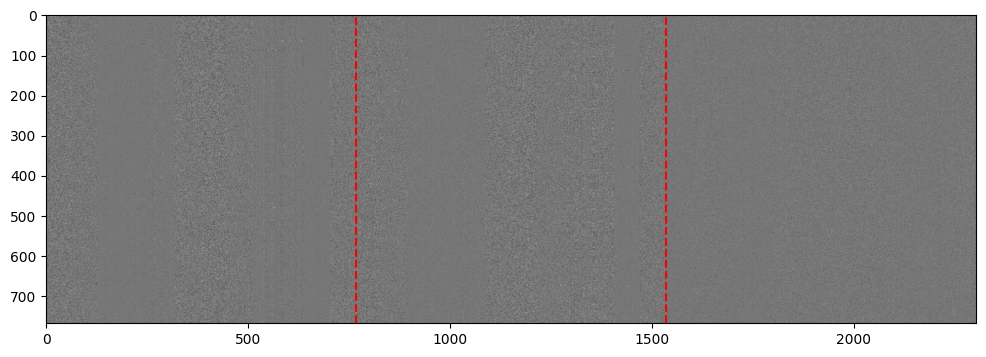

In [21]:
# --- 下面是新的代码，用来更清晰地展示结构 ---
import torch

# 获取权重张量
QKV = sd_hf["transformer.h.1.attn.c_attn.weight"]
n_embd = model_hf.config.n_embd # 768

# 1. 打印形状来证明结构
print(f"完整的 c_attn.weight 形状: {QKV.shape}")
print(f"嵌入维度 (n_embd): {n_embd}")
print(f"宽度是嵌入维度的 {QKV.shape[1] / n_embd} 倍")

# 2. 将Q, K, V的权重拆分开
q_w, k_w, v_w = torch.split(QKV, n_embd, dim=1)
print(f"拆分后 Q, K, V 的形状: {q_w.shape}, {k_w.shape}, {v_w.shape}")

# 3. 计算每个部分的统计数据，可以看到它们的数值分布有微小差异
print(f"\nQ, K, V 权重的均值: {q_w.mean():.6f}, {k_w.mean():.6f}, {v_w.mean():.6f}")
print(f"Q, K, V 权重的标准差: {q_w.std():.6f}, {k_w.std():.6f}, {v_w.std():.6f}")

# 4. 在图上画出分割线
plt.figure(figsize=(12, 4))
plt.imshow(QKV, cmap="gray", aspect='auto')
# 在 768 和 1536 的位置画上红色虚线
plt.axvline(x=n_embd, color='r', linestyle='--')
plt.axvline(x=2*n_embd, color='r', linestyle='--')
plt.show()

周期性最强的前5列是: [744 237 603 696 447]
周期性处于中位数附近的5列是: [366 650 110 381 698]
Figure saved to wpe_periodicity.png


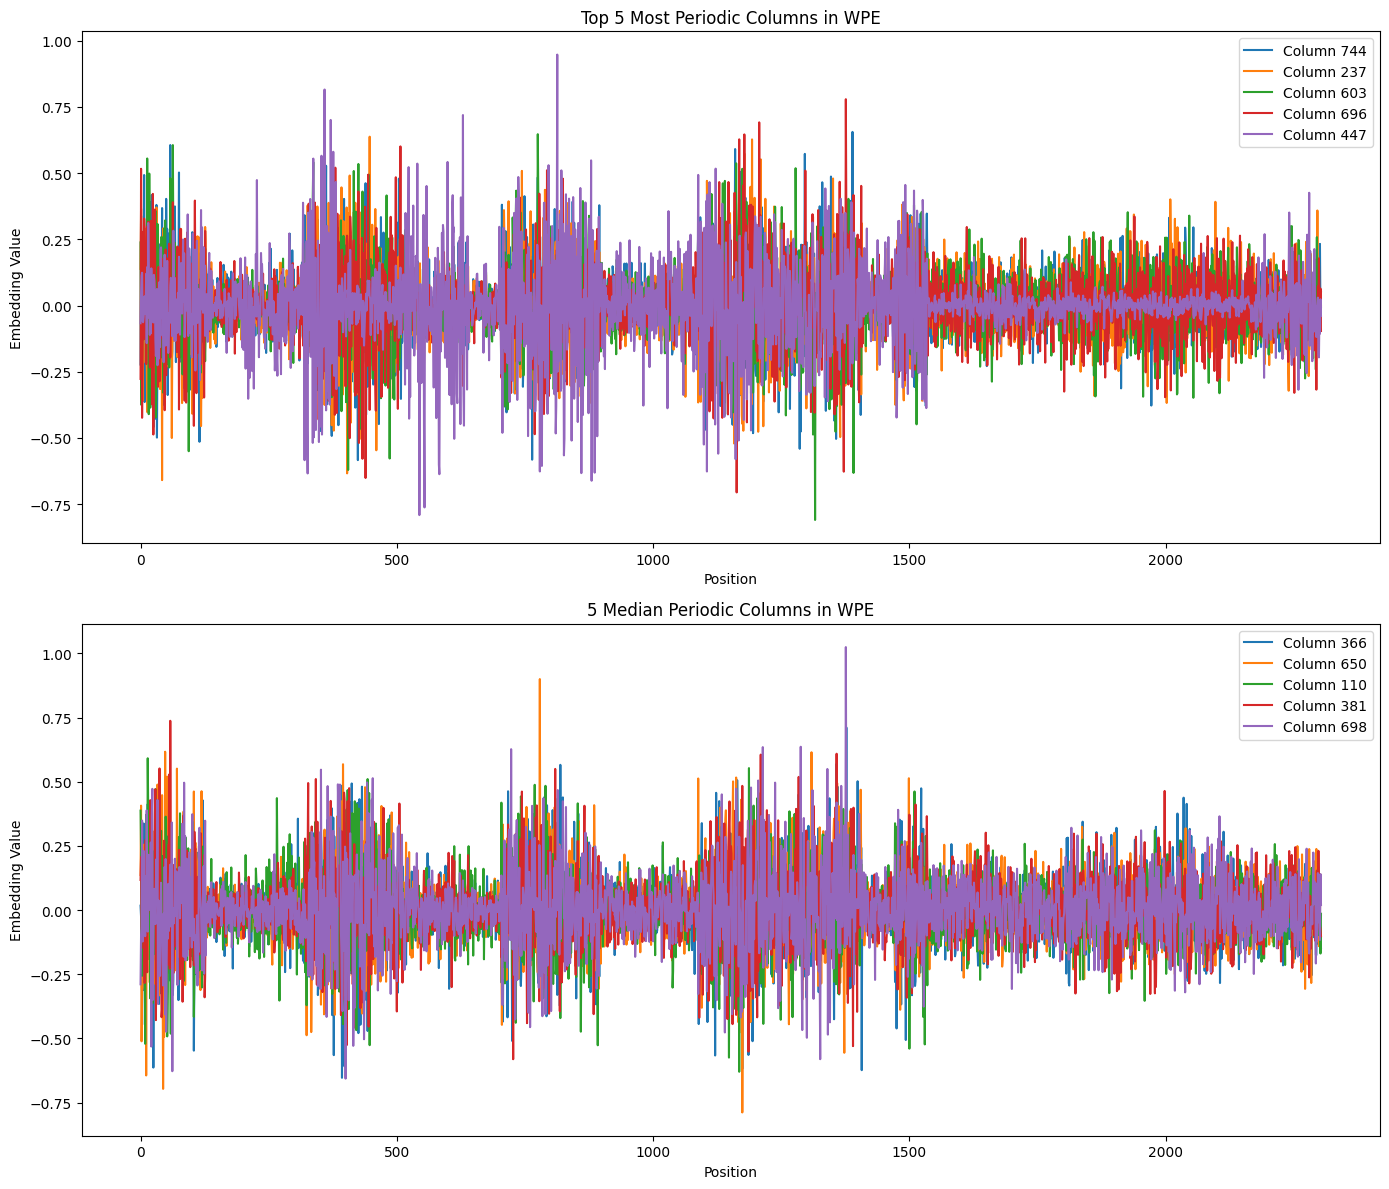

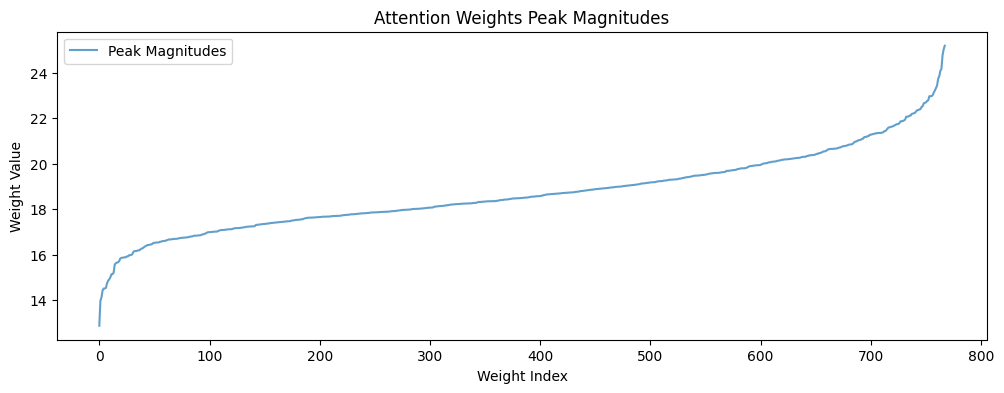

In [22]:
# Q = QKV[:n_embd, :]
# K = QKV[n_embd:2*n_embd, :]
# V = QKV[2*n_embd:3*n_embd, :]
analyze_and_plot_wpe_periodicity(QKV.T, save_path="wpe_periodicity.png")

周期性最强的前5列是: [1303 1316 1184  407   55]
周期性处于中位数附近的5列是: [1608  886 1972 2138 1327]
Figure saved to wpe_periodicity.png


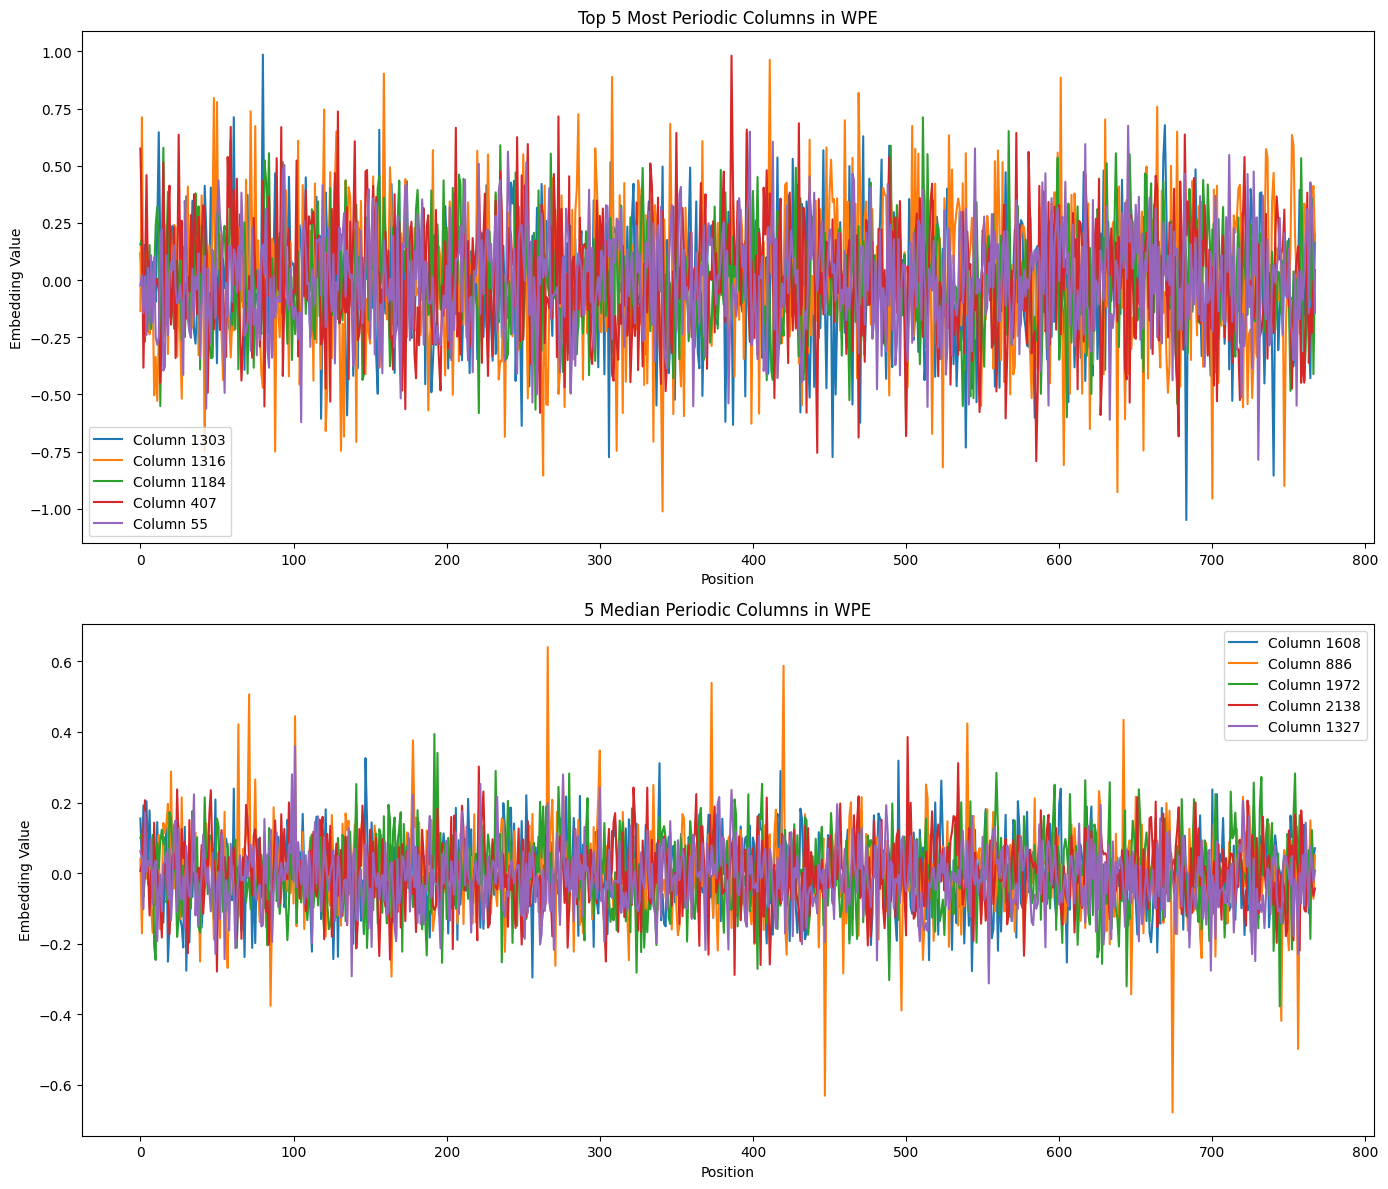

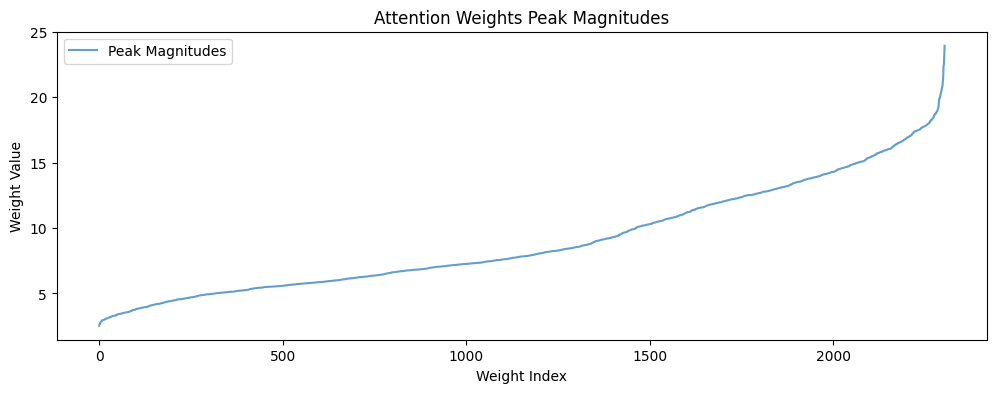

In [23]:
analyze_and_plot_wpe_periodicity(QKV, save_path="wpe_periodicity.png")

您观察得非常仔细！这张图确实揭示了Q、K、V权重矩阵在结构上的微妙差异，这源于它们在自注意力机制中扮演的不同角色。

虽然三者看起来都像随机噪声，但它们的“纹理”是不同的，这正是模型在训练中为实现不同功能而学习到的结果：

1.  **Q (查询) 和 K (键) - 负责匹配**
    *   **作用**: Q和K的主要任务是相互配合，通过点积运算（`Q @ K.T`）来计算出序列中每个词对其他词的“注意力分数”或“相关性”。
    *   **结构**: 因此，Q矩阵和K矩阵的权重被优化为能够有效地进行“匹配”。它们学习到的结构（图中那些非常微弱的、几乎看不见的垂直纹理）是为了让有意义的词对能够产生高的点积得分，而无关的词对得分较低。你可以把它们想象成一个高度复杂的“锁和钥匙”系统。

2.  **V (值) - 负责提供信息**
    *   **作用**: V矩阵不参与计算注意力分数。它的作用是在分数计算完毕后，作为一个“信息提供者”。最终的输出是V向量的加权平均，权重就是Q和K算出来的分数。
    *   **结构**: 因此，V矩阵的权重被优化为能够包含丰富、多样的语义信息。它不需要像Q和K那样有“匹配”结构，所以它的权重看起来更像均匀的、高熵的噪声，这正是一个好的信息源的特征。

**总结一下：**

*   **前两个块 (Q, K)**：看起来略有结构，因为它们是“匹配器”，需要协同工作。
*   **第三个块 (V)**：看起来更随机，因为它是“信息库”，负责提供内容。

这种功能上的分离，导致了它们在权重上呈现出这些细微但有意义的结构差异。

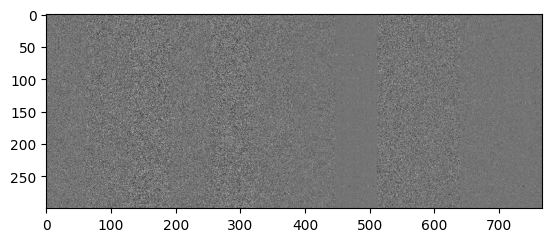

In [24]:
QKV = sd_hf["transformer.h.2.attn.c_attn.weight"]
plt.imshow(QKV[:300,:767], cmap="gray")

# save the fig
plt.savefig("attention_weights.png")

plt.show()

# Generate

In [25]:
from transformers import pipeline, set_seed
generator = pipeline('text-generation', model='gpt2')
set_seed(42)
generator("Hello, I love physics, ", max_length=30, num_return_sequences=5)


Device set to use cuda:0
Truncation was not explicitly activated but `max_length` is provided a specific value, please use `truncation=True` to explicitly truncate examples to max length. Defaulting to 'longest_first' truncation strategy. If you encode pairs of sequences (GLUE-style) with the tokenizer you can select this strategy more precisely by providing a specific strategy to `truncation`.
Setting `pad_token_id` to `eos_token_id`:50256 for open-end generation.
Both `max_new_tokens` (=256) and `max_length`(=30) seem to have been set. `max_new_tokens` will take precedence. Please refer to the documentation for more information. (https://huggingface.co/docs/transformers/main/en/main_classes/text_generation)


[{'generated_text': 'Hello, I love physics, "\n"But you\'re right, it\'s not a physics game. You could make a 3D game with it! I\'m sure you can make a 3D game with a little different mechanics."\n"Well, I think we\'ve found a way to make a game with physics."\n"But I\'m sure you could make a game with it too. I wonder if the physics would be much better?"\n"Don\'t worry, I\'ll get some really awesome physics to compare to. It\'s going to take some time, but I\'ll be sure to check it out! It\'s going to be really fun to play!"\n"I guess so... I see."\n"Oh, well, I\'m sure I can make a game with the physics for you..."\n"No... I want to make a game that you can play!"\n"Yes! I want to play!"\n"What\'s your name, dear?"\n"My father is a physicist. He studied physics at the University of California at Berkeley for a long time. I am a physicist. But I\'m not a physicist."\n"I\'m actually a physicist."\n"But you can\'t make a computer that moves. You can\'t make a computer that has a human'

In [40]:
# let's instead sample manually
import torch
from torch.nn import functional as F

model = GPT2LMHeadModel.from_pretrained("gpt2") # 124M
model.eval()
model.to('cuda')
torch.manual_seed(42)
torch.cuda.manual_seed(42)
# tokens = [1, 2, 3, 4, 5, 6, 7] # Replace with actual token IDs
tokens = [15496, 11, 314, 1101, 257, 3303, 2746] # "Hello, I'm a language model"
# tokens = [15496, 11, 314, 1101, 257, 3303, 2746, 11] # "Hello, I'm a language model,"
tokens = torch.tensor(tokens, dtype=torch.long) # (8,)
tokens = tokens.unsqueeze(0).repeat(5, 1) # (5, 8)
x = tokens.to('cuda')

# generate!
while x.size(1) < 30: # max_length=30
    # forward the model to get the logits
    with torch.no_grad():
        logits = model(x)[0] # (B, T, vocab_size)
        # take the logits at the last position
        logits = logits[:, -1, :] # (B, vocab_size)
        # get the probabilities
        probs = F.softmax(logits, dim=-1)
        # do top-k sampling of 50 (huggingface pipeline default)
        # topk_probs here becomes (5, 50), topk_indices is (5, 50)
        topk_probs, topk_indices = torch.topk(probs, 50, dim=-1)
        # select a token from the top-k probabilities
        # note: multinomial does not demand the input to sum to 1
        ix = torch.multinomial(topk_probs, 1) # (B, 1)
        # gather the corresponding indices
        xcol = torch.gather(topk_indices, -1, ix) # (B, 1)
        # append to the sequence
        x = torch.cat((x, xcol), dim=1)

# print the generated text
import tiktoken
enc = tiktoken.get_encoding('gpt2')
for i in range(5):
    tokens = x[i, :30].tolist()
    decoded = enc.decode(tokens)
    print(">", decoded)

> Hello, I'm a language modeler. In fact I use that name from C# to describe our development and development workflow. We have many different
> Hello, I'm a language model. Language models are not that complicated unless you know to change the behavior of some of your functions, of the variable
> Hello, I'm a language model. I make the syntax based on it. For example, it can be used to define the syntax of a language
> Hello, I'm a language modeler - I like to do a lot of abstraction and I've also seen the ability to generate generic programming languages like
> Hello, I'm a language model that has a language model in the domain of computer biology. If you study computer systems in your undergraduate degree or at


In [27]:
# tiny shakespeare dataset
# !wget https://raw.githubusercontent.com/karpathy/char-rnn/master/data/tinyshakespeare/input.txt
with open('input.txt', 'r') as f:
    text = f.read()
data = text[:1000] # first 1,000 characters
print(data[:100])

First Citizen:
Before we proceed any further, hear me speak.

All:
Speak, speak.

First Citizen:
You


In [28]:
import tiktoken
enc = tiktoken.get_encoding('gpt2')
tokens = enc.encode(data)
print(tokens[:24])

[5962, 22307, 25, 198, 8421, 356, 5120, 597, 2252, 11, 3285, 502, 2740, 13, 198, 198, 3237, 25, 198, 5248, 461, 11, 2740, 13]


In [29]:
import torch
buf = torch.tensor(tokens[:24 + 1])
x = buf[:-1].view(4, 6)
y = buf[1:].view(4, 6)
print(x)
print(y)

tensor([[ 5962, 22307,    25,   198,  8421,   356],
        [ 5120,   597,  2252,    11,  3285,   502],
        [ 2740,    13,   198,   198,  3237,    25],
        [  198,  5248,   461,    11,  2740,    13]])
tensor([[22307,    25,   198,  8421,   356,  5120],
        [  597,  2252,    11,  3285,   502,  2740],
        [   13,   198,   198,  3237,    25,   198],
        [ 5248,   461,    11,  2740,    13,   198]])


In [30]:
print(sd_hf["lm_head.weight"].shape)
print(sd_hf["transformer.wte.weight"].shape)

torch.Size([50257, 768])
torch.Size([50257, 768])


In [31]:
(sd_hf["lm_head.weight"] == sd_hf["transformer.wte.weight"]).all()

tensor(True)

In [32]:
print(sd_hf["lm_head.weight"].data_ptr())
print(sd_hf["transformer.wte.weight"].data_ptr())

1769601019859
1769601019859


In [111]:
# standard deviation grows inside the residual stream
x = torch.zeros(768)
n = 100 # e.g. 100 layers
for i in range(n):
    x += torch.randn(768)

print(x.std())

tensor(10.0171)


In [100]:

# standard deviation grows inside the residual stream
x = torch.zeros(768)
n = 100 # e.g. 100 layers
for i in range(n):
    x += n**-0.5 * torch.randn(768)

print(x.std())

tensor(0.9805)


In [34]:
import torch

# super simple little MLP
net = torch.nn.Sequential(
    torch.nn.Linear(16, 32),
    torch.nn.GELU(),
    torch.nn.Linear(32, 1)
)
torch.random.manual_seed(42)
x = torch.randn(4, 16)
y = torch.randn(4, 1)
net.zero_grad()
yhat = net(x)
loss = torch.nn.functional.mse_loss(yhat, y)
loss.backward()
print(net[0].weight.grad.view(-1)[:10])

# the loss objective here is (due to readuction='mean')
# L = 1/4 * [
#            (y[0] - yhat[0])**2 +
#            (y[1] - yhat[1])**2 +
#            (y[2] - yhat[2])**2 +
#            (y[3] - yhat[3])**2
#           ]
# NOTE: 1/4!

tensor([ 0.0280,  0.0069, -0.0034, -0.0073, -0.0051,  0.0042,  0.0109,  0.0212,
         0.0247,  0.0105])


In [35]:
# now let's do it with grad_accum_steps of 4, and B=1
# the loss objective here is different because
# accumulation in gradient <---> SUM in loss
# i.e. we instead get:
# L0 = 1/4(y[0] - yhat[0])**2
# L1 = 1/4(y[1] - yhat[1])**2
# L2 = 1/4(y[2] - yhat[2])**2
# L3 = 1/4(y[3] - yhat[3])**2
# L = L0 + L1 + L2 + L3
# NOTE: the "normalizer" of 1/4 is lost
net.zero_grad()
for i in range(4):
    yhat = net(x[i])
    loss = torch.nn.functional.mse_loss(yhat, y[i])
    loss = loss / 4 # <-- have to add back the "normalizer"!
    loss.backward()
print(net[0].weight.grad.view(-1)[:10])


tensor([ 0.0280,  0.0069, -0.0034, -0.0073, -0.0051,  0.0042,  0.0109,  0.0212,
         0.0247,  0.0105])


In [36]:
# parse and visualize the logfile
import numpy as np
import matplotlib.pyplot as plt
%matplotlib inline

sz = "124M"

loss_baseline = {
    "124M": 3.2924,
}[sz]
hella2_baseline = { # HellaSwag for GPT-2
    "124M": 0.294463,
    "350M": 0.375224,
    "774M": 0.431986,
    "1558M": 0.488946,
}[sz]
hella3_baseline = { # HellaSwag for GPT-3
    "124M": 0.337,
    "350M": 0.436,
    "774M": 0.510,
    "1558M": 0.547,
}[sz]

# load the log file
with open("log124M_40B/log.txt", "r") as f:
    lines = f.readlines()

# parse the individual lines, group by stream (train,val,hella)
streams = {}
for line in lines:
    step, stream, val = line.strip().split()
    if stream not in streams:
        streams[stream] = {}
    streams[stream][int(step)] = float(val)

# convert each stream from {step: val} to (steps[], vals[])
# so it's easier for plotting
streams_xy = {}
for k, v in streams.items():
    # get all (step, val) items, sort them
    xy = sorted(list(v.items()))
    # unpack the list of tuples to tuple of lists
    streams_xy[k] = list(zip(*xy))

# create figure
plt.figure(figsize=(16, 6))

# Panel 1: losses: both train and val
plt.subplot(121)
xs, ys = streams_xy["train"] # training loss
ys = np.array(ys)
plt.plot(xs, ys, label=f'nanogpt ({sz}) train loss')
print("Min Train Loss:", min(ys))
xs, ys = streams_xy["val"] # validation loss
plt.plot(xs, ys, label=f'nanogpt ({sz}) val loss')
# horizontal line at GPT-2 baseline
if loss_baseline is not None:
    plt.axhline(y=loss_baseline, color='r', linestyle='--', label=f"OpenAI GPT-2 ({sz}) checkpoint val loss")
plt.xlabel("steps")
plt.ylabel("loss")
plt.yscale('log')
plt.ylim(top=4.0)
plt.legend()
plt.title("Loss")
print("Min Validation Loss:", min(ys))

# Panel 2: HellaSwag eval
plt.subplot(122)
xs, ys = streams_xy["hella"] # HellaSwag eval
ys = np.array(ys)
plt.plot(xs, ys, label=f"nanogpt ({sz})")
# horizontal line at GPT-2 baseline
if hella2_baseline:
    plt.axhline(y=hella2_baseline, color='r', linestyle='--', label=f"OpenAI GPT-2 ({sz}) checkpoint")
if hella3_baseline:
    plt.axhline(y=hella3_baseline, color='g', linestyle='--', label=f"OpenAI GPT-3 ({sz}) checkpoint")
plt.xlabel("steps")
plt.ylabel("accuracy")
plt.legend()
plt.title("HellaSwag eval")
print("Max Hellaswag eval:", max(ys))

FileNotFoundError: [Errno 2] No such file or directory: 'log124M_40B/log.txt'